In [32]:
import json
import pandas as pd

with open("likes_and_reactions.json", "r", encoding="utf-8") as file:
    facebook_data = json.load(file)

type(facebook_data)

list

In [33]:
len(facebook_data)

6942

In [34]:
facebook_data[0]

{'timestamp': 1788359877,
 'media': [],
 'label_values': [{'label': 'Reaction', 'value': 'Like'},
  {'label': 'URL',
   'value': 'https://www.facebook.com/reel/1718762373051401/',
   'href': 'https://www.facebook.com/reel/1718762373051401/'},
  {'label': 'Title', 'value': ''},
  {'label': 'Name', 'value': 'Dominique Baked Bougie Bestie'}],
 'fbid': '10237833770245809'}

In [36]:
facebook_data[0].keys()

dict_keys(['timestamp', 'media', 'label_values', 'fbid'])

In [37]:
facebook_data[0]["label_values"][0]

{'label': 'Reaction', 'value': 'Like'}

In [38]:
facebook_data[0]["label_values"][0]["value"]

'Like'

In [39]:
facebook_data[0]["label_values"][1]

{'label': 'URL',
 'value': 'https://www.facebook.com/reel/1718762373051401/',
 'href': 'https://www.facebook.com/reel/1718762373051401/'}

In [40]:
facebook_data[0]["label_values"][2]

{'label': 'Title', 'value': ''}

In [41]:
facebook_data[0]["label_values"][3]

{'label': 'Name', 'value': 'Dominique Baked Bougie Bestie'}

In [42]:
facebook_data[0]["label_values"][3]["value"]

'Dominique Baked Bougie Bestie'

In [43]:
facebook_data[0]["label_values"]
facebook_data[1]["label_values"]
facebook_data[2]["label_values"]
facebook_data[10]["label_values"]

[{'label': 'Reaction', 'value': 'Like'},
 {'label': 'URL',
  'value': 'https://www.facebook.com/reel/27859652766978233/',
  'href': 'https://www.facebook.com/reel/27859652766978233/'},
 {'label': 'Title', 'value': ''},
 {'label': 'Name', 'value': 'Kash Kyla'}]

In [44]:
facebook_data[0]["label_values"][3]["value"]

'Dominique Baked Bougie Bestie'

In [45]:
rows = []

for post in facebook_data:
    timestamp = post["timestamp"]
    reaction = None
    name = None

    for item in post["label_values"]:

        if item.get("label") == "Reaction":
            reaction = item.get("value")

        if item.get("label") == "Name":
            name = item.get("value")

    rows.append({
        "timestamp": timestamp,
        "reaction": reaction,
        "name": name
    })
    

In [46]:
facebook_df = pd.DataFrame(rows)

facebook_df["timestamp"] = pd.to_datetime(
    facebook_df["timestamp"],
    unit="s"
)

facebook_df.head()

,timestamp,reaction,name
0,2026-09-02 14:37:57,Like,Dominique Baked Bougie Bestie
1,2026-09-01 13:12:53,Like,Daii Lynnaee
2,2026-08-19 03:39:49,Love,Clark Burks
3,2026-08-09 21:59:46,Like,Stevelam
4,2026-08-03 14:26:21,Like,Maegen's Glitz and Glam


In [47]:
facebook_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6942 entries, 0 to 6941
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype        
---  ------     --------------  -----        
 0   timestamp  6942 non-null   datetime64[s]
 1   reaction   6847 non-null   str          
 2   name       5193 non-null   str          
dtypes: datetime64[s](1), str(2)
memory usage: 264.0 KB


In [48]:
facebook_df["reaction"].value_counts()

reaction
Like        3143
Love        3132
Haha         407
Sad          128
Angry         17
Wow           16
Thankful       4
Name: count, dtype: int64

In [49]:
facebook_df.groupby("name")["timestamp"].count()

name
#TeamNatural                                              2
123world                                                  1
1980s Memory Lane                                         1
410dwill45 TV                                             1
5-Minute Crafts Play                                      1
                                                         ..
reignstormpit                                             1
restockmyhome                                             1
shanicelashaystyle                                        1
soapcute_california                                       1
ð
ðð·ð ðð ððððððð    1
Name: timestamp, Length: 795, dtype: int64

In [50]:
facebook_df.groupby("name")["timestamp"].count().sort_values(
    ascending=False
)

name
Jackie FG                                                 387
Crystal Ray                                               237
Brannette Annese Parker                                   195
Noni Niambi Brooks                                        189
Dani Dani                                                 141
                                                         ... 
Kikiz Cosmeticz                                             1
Carmen Stroud                                               1
Kimiko Jones                                                1
Kimla áá·áá¡á¶                                       1
ð
ðð·ð ðð ððððððð      1
Name: timestamp, Length: 795, dtype: int64

In [51]:
facebook_df.groupby("name")["timestamp"].count().sort_values(
    ascending=False
)

name
Jackie FG                                                 387
Crystal Ray                                               237
Brannette Annese Parker                                   195
Noni Niambi Brooks                                        189
Dani Dani                                                 141
                                                         ... 
Kikiz Cosmeticz                                             1
Carmen Stroud                                               1
Kimiko Jones                                                1
Kimla áá·áá¡á¶                                       1
ð
ðð·ð ðð ððððððð      1
Name: timestamp, Length: 795, dtype: int64

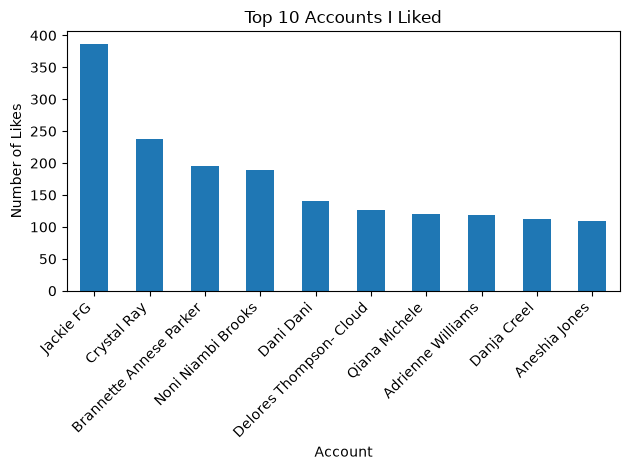

In [54]:

facebook_df.groupby("name")["timestamp"].count().sort_values(
    ascending=False
).head(10).plot(
    kind="bar",
    title="Top 10 Accounts I Liked",
    xlabel="Account",
    ylabel="Number of Likes"
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Hypothesis

I hypothesize that the number of social media accounts I followed changed over time, with some years having more new follows than others.

### Theoretical Element

My theoretical idea is that my social media interests and activity changed over time. Because of this, I would expect the number of accounts I followed to be different from year to year.

### Statistical Element

The statistical part of my hypothesis is that I can count the number of accounts followed during each year and compare the yearly totals. This allows me to look for a pattern in my following activity.

## Second Data File

I chose the `who_you've_followed.json` file because it contains information about the accounts I followed. The file contains account names and timestamps showing when the accounts were followed.

This file can help test my hypothesis because I can use the timestamps to determine the year when I followed each account. I can then count how many accounts I followed during each year and compare the results.

In [55]:
with open("who_you've_followed.json", "r") as file:
    following_data = json.load(file)

following_df = pd.DataFrame(
    following_data["following_v3"]
)

following_df.head(10)

,name,timestamp
0,Summer Reign Henning,1787428389
1,Magnus Rug Cleaning,1784070667
2,Khy Epp,1769189771
3,Jonea Patton,1756593182
4,Vixit Dressing,1754954628
5,Kasoy tv,1753330386
6,Sandra Glover Prude,1750378867
7,WatchCut,1748645002
8,Wlosowero,1748211969
9,Teamsters Local 507,1741188496


In [58]:
following_df["date"] = pd.to_datetime(
    following_df["timestamp"], unit="s"
)

following_df["year"] = following_df["date"].dt.year

following_df.head(10)

,name,timestamp,date,year
0,Summer Reign Henning,1787428389,2026-08-22 19:53:09,2026
1,Magnus Rug Cleaning,1784070667,2026-07-14 23:11:07,2026
2,Khy Epp,1769189771,2026-01-23 17:36:11,2026
3,Jonea Patton,1756593182,2025-08-30 22:33:02,2025
4,Vixit Dressing,1754954628,2025-08-11 23:23:48,2025
5,Kasoy tv,1753330386,2025-07-24 04:13:06,2025
6,Sandra Glover Prude,1750378867,2025-06-20 00:21:07,2025
7,WatchCut,1748645002,2025-05-30 22:43:22,2025
8,Wlosowero,1748211969,2025-05-25 22:26:09,2025
9,Teamsters Local 507,1741188496,2025-03-05 15:28:16,2025


In [59]:
follows_by_year = (
    following_df.groupby("year")["name"].count()
)

follows_by_year

year
2015     54
2016    137
2017     70
2018      8
2019      3
2020     25
2021     12
2022      5
2023     14
2024     11
2025      7
2026      3
Name: name, dtype: int64

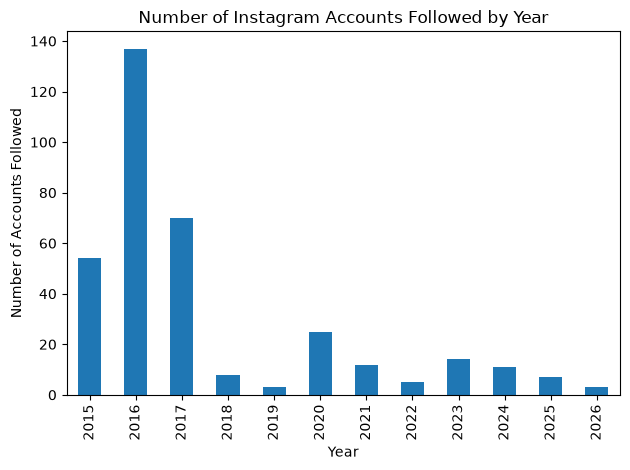

In [60]:
follows_by_year.plot(
    kind="bar",
    title="Number of Instagram Accounts Followed by Year",
    xlabel="Year",
    ylabel="Number of Accounts Followed"
)

plt.tight_layout()
plt.show()


## DataFrame Explanation

The DataFrame represents the Instagram accounts I followed and the time when I followed them. The original JSON data had a nested structure, so I converted the `following_v3` data into a DataFrame.

The DataFrame is mostly tidy because each row represents one account I followed and the columns represent different variables, such as the account name, timestamp, date, and year.

This DataFrame is useful for my hypothesis because I can use the year to count how many accounts I followed over time.

One thing that was confusing about the data was that the timestamps were stored as numbers instead of normal dates. I had to convert the timestamps into dates before I could easily analyze the data.

## Results and Conclusion

My results show that the number of accounts I followed changed over time. Some years had more follows than other years.

The results allow me to compare my following activity from year to year. This helps me evaluate my hypothesis because the data shows that my following activity was not the same every year.

However, the data only shows when I followed accounts. It does not explain why my following activity changed.

## Limitations

One limitation is that the data may not contain every detail about my social media behavior. It also does not explain why I followed an account.

Another limitation is that following an account does not necessarily mean that I regularly interacted with that account. The data only tells me that the account was followed at a certain time.

The reaction data also has limitations because it shows reactions but does not explain why I reacted to a post.

## Alternative Explanations

The changes in my following activity could have been caused by changes in my interests, how often I used social media, or changes in the types of accounts I was interested in.

Another possibility is that I simply had more reasons to follow accounts during certain years than during other years.

## Next Steps

For future analysis, I could compare my following activity with my likes and reactions. I could also look at the types of accounts I interacted with to see if my interests changed over time.

I could also analyze the reactions by year to see whether my overall social media activity changed in a similar way.